In [10]:
library(readr)
library(tidyverse)
MIUDS_2 <-
    read_tsv("04652-0001-Data.tsv")

Rows: 4963 Columns: 2189
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr    (1): B1PSOC
dbl (2188): M2ID, M2FAMNUM, SAMPLMAJ, B1STATUS, B1PAGE_M2, B1PRAGE_2019, M2A...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
head(MIUDS_2)

M2ID,M2FAMNUM,SAMPLMAJ,B1STATUS,B1PAGE_M2,B1PRAGE_2019,M2AGE_FLAG,B1PBYEAR,B1PBYEAR_2019,M2BYEAR_FLAG,⋯,B1SP3I,B1SP3J,B1SP4,B1SP5,B1SQ1,B1SQ2,B1SQ3,B1SQ4,B1SQ5,B1SQ6
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10001,110498,2,2,61,61,0,1943,1943,0,⋯,8,8,8,8,8,5,7,8,8,8
10002,100001,1,2,69,69,0,1935,1935,0,⋯,8,8,8,8,9,9,9,7,6,10
10005,120803,3,2,80,80,0,1924,1924,0,⋯,8,8,8,8,10,10,10,10,10,10
10006,120772,3,1,60,60,0,1944,1944,0,⋯,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
10010,120378,3,2,55,55,0,1948,1948,0,⋯,2,2,3,3,8,8,8,9,9,9
10011,110475,2,2,52,52,0,1952,1952,0,⋯,2,1,4,4,8,10,9,9,10,8


Respondent_ID,Sex,Self_Reported_Physical_Health
<dbl>,<dbl>,<dbl>
10001,1,4
10002,1,1
10005,2,2
10006,2,3
10010,1,2
10011,2,1


[1] 4963    3

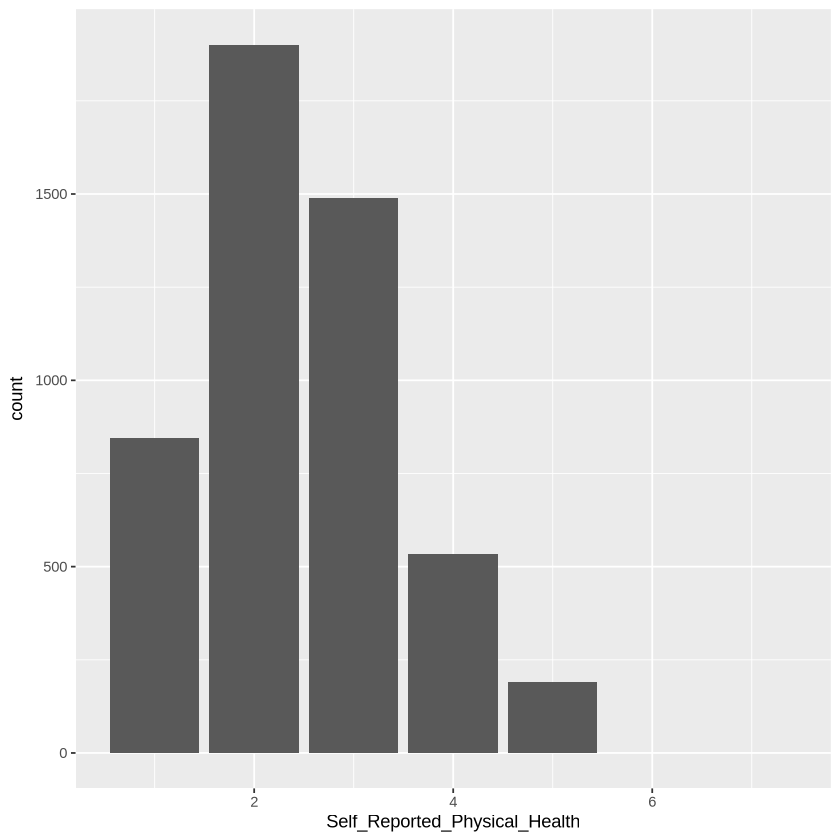

In [26]:
# Q1: Is there a statistically significant difference in self-reported physical health between males and females? 
MIUDS_2_selected <- MIUDS_2 |>
                    select(M2ID, B1PRSEX, B1PA1) |>
                    rename(
                        Respondent_ID = M2ID,
                        Sex = B1PRSEX,
                        Self_Reported_Physical_Health = B1PA1)
head(MIUDS_2_selected)
dim(MIUDS_2_selected)

sleep_hours_plot <- MIUDS_2_selected |>
                    ggplot() +
                    geom_bar(aes(x = Self_Reported_Physical_Health))
sleep_hours_plot

# Grouping Variable: Sex (B1PRSEX)
# Outcome Variable: Mental Health (B1PA2) — 1 = Excellent, 5 = Poor

Respondent_ID,Sex,Sleep_Hours
<dbl>,<dbl>,<dbl>
10001,1,1
10002,1,1
10005,2,1
10006,2,1
10010,1,1
10011,2,1


Respondent_ID,Sex,Sleep_Hours
<dbl>,<dbl>,<dbl>
19185,2,1
19186,2,2
19187,1,1
19190,2,1
19191,2,1
19193,1,1


[1] 4963    3

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


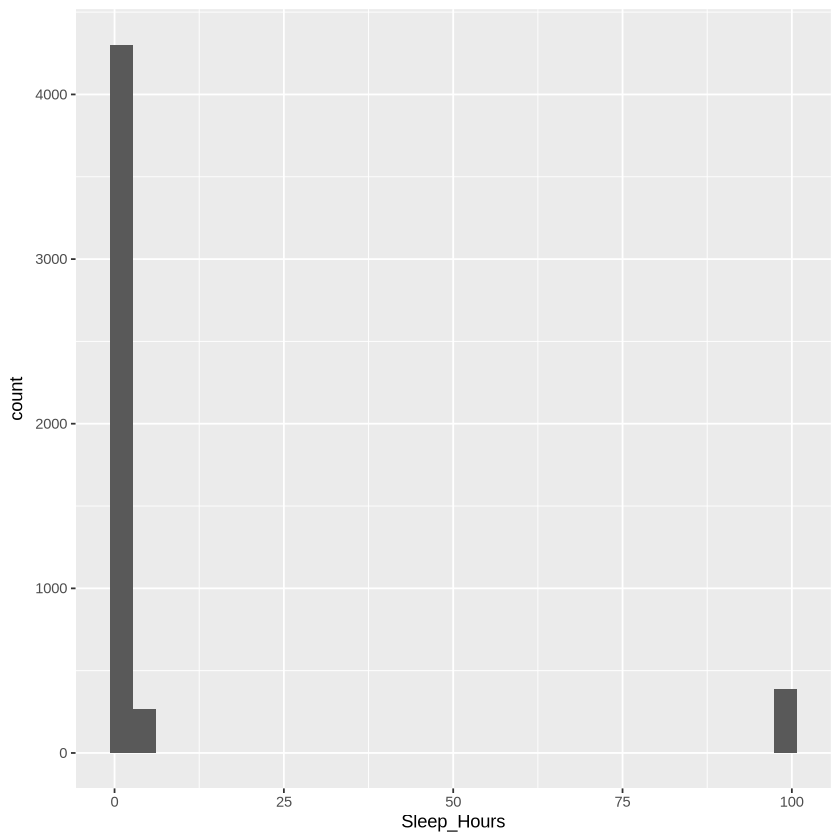

In [25]:
# Q2: Is there a statistically significant difference in average nightly sleep duration between males and females?
MIUDS_2_selected_2 <- MIUDS_2 |>
                      select(M2ID, B1PRSEX, B1PB20) |>
                      rename(
                          Respondent_ID = M2ID,
                          Sex = B1PRSEX,
                          Sleep_Hours = B1PB20)
head(MIUDS_2_selected_2)
tail(MIUDS_2_selected_2)
dim(MIUDS_2_selected_2)

sleep_hours_plot <- MIUDS_2_selected_2 |>
                    ggplot() +
                    geom_histogram(aes(x = Sleep_Hours))
sleep_hours_plot

Respondent_ID,Work_Status,Sleep_Hours,Employment_Group
<dbl>,<dbl>,<dbl>,<chr>
10001,9,1,Not Employed
10002,12,1,Not Employed
10005,3,1,Employed
10006,6,1,Not Employed
10010,5,1,Not Employed
10011,11,1,Not Employed


Respondent_ID,Work_Status,Sleep_Hours,Employment_Group
<dbl>,<dbl>,<dbl>,<chr>
19185,6,1,Not Employed
19186,5,2,Not Employed
19187,6,1,Not Employed
19190,11,1,Not Employed
19191,5,1,Not Employed
19193,11,1,Not Employed


[1] 4963    4

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


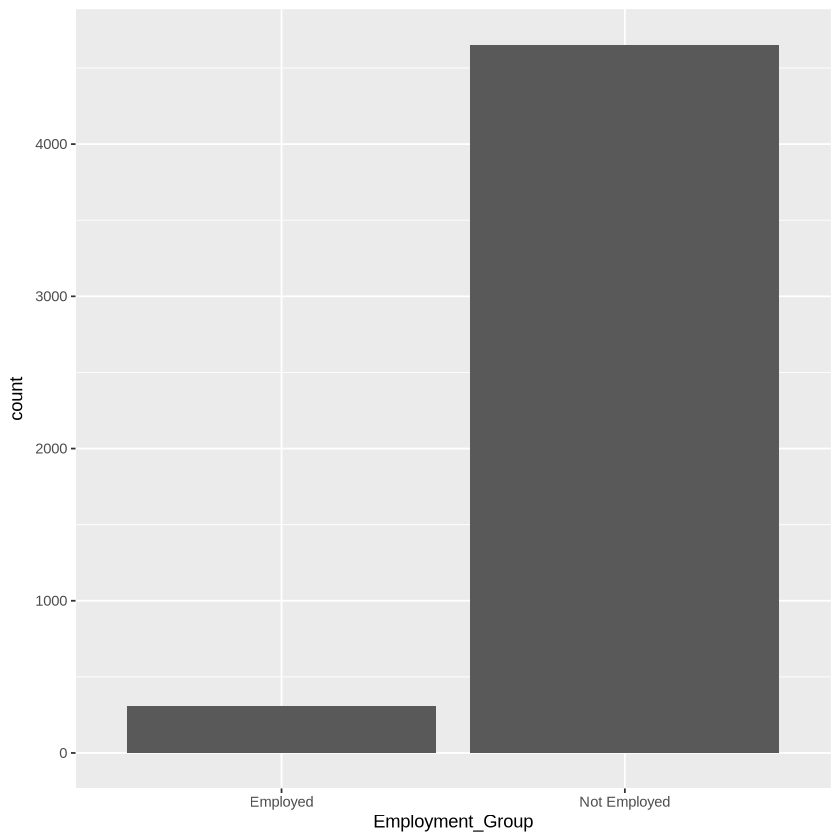

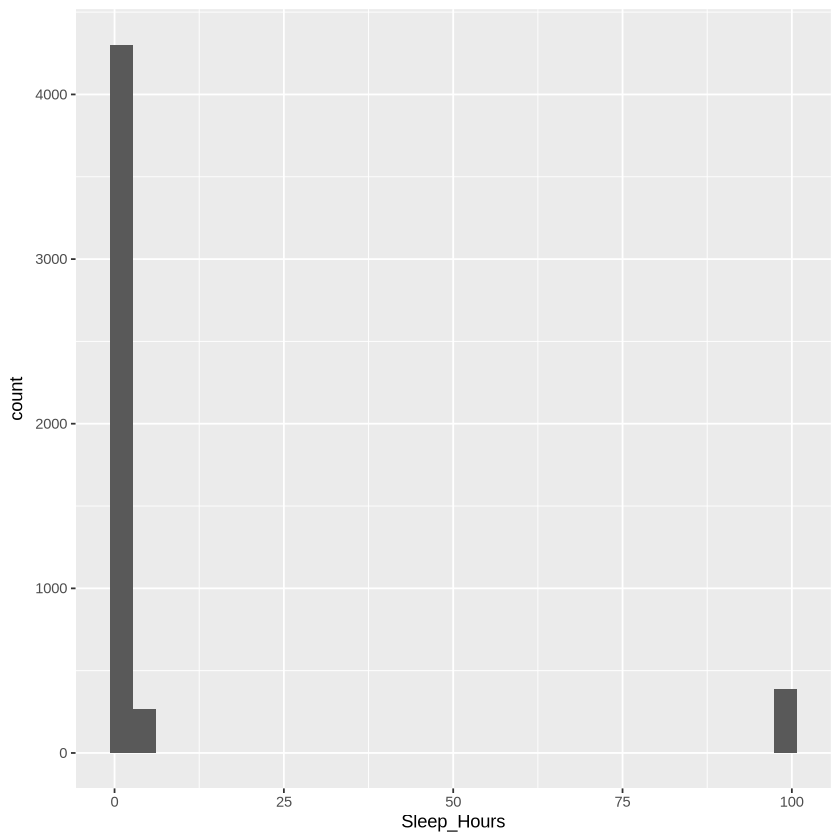

In [35]:
#Q3: Is there a statistically significant difference in average nightly sleep duration between currently employed adults and non-employed adults?

#Strategy 1: Employed vs. Not Employed
# 问题：Employed vs. Not Employed人数差异大 but Welch's t-test can handle unequal n automatically.
# Code	Category Description
# 1	Working full-time for pay
# 2	Working part-time for pay
# 3	Self-employed
# 1-3 Employed


# 4	Unemployed / Looking for work
# 5	Retired
# 6	Homemaker
# 7	Student
# 8	Permanently disabled / Sick
# 9	Temporarily laid off / On leave
# 10	Unpaid family worker
# 11	Volunteer
# 12	Other
# 4-12 Not Employed
MIUDS_2_selected_3 <- MIUDS_2 |>
                      select(M2ID, B1PB1, B1PB20) |>
                      rename(
                          Respondent_ID = M2ID,
                          Work_Status = B1PB1,
                          Sleep_Hours = B1PB20) |>
                            mutate(
    Employment_Group = ifelse(Work_Status %in% c(1, 2, 3), "Employed", "Not Employed")
  )
head(MIUDS_2_selected_3)
tail(MIUDS_2_selected_3)
dim(MIUDS_2_selected_3)

employment_plot <- MIUDS_2_selected_3 |>
                   ggplot() +
                   geom_bar(aes(x = Employment_Group))
employment_plot

sleep_hours_plot <- MIUDS_2_selected_3 |>
                    ggplot() +
                    geom_histogram(aes(x = Sleep_Hours))
sleep_hours_plot

Respondent_ID,Work_Status,Sleep_Hours,Employment_Group
<dbl>,<dbl>,<dbl>,<chr>
10001,9,1,Not Employed
10002,12,1,Not Employed
10005,3,1,Employed
10006,6,1,Not Employed
10010,5,1,Not Employed
10011,11,1,Not Employed


Respondent_ID,Work_Status,Sleep_Hours,Employment_Group
<dbl>,<dbl>,<dbl>,<chr>
19185,6,1,Not Employed
19186,5,2,Not Employed
19187,6,1,Not Employed
19190,11,1,Not Employed
19191,5,1,Not Employed
19193,11,1,Not Employed


[1] 4963    4

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


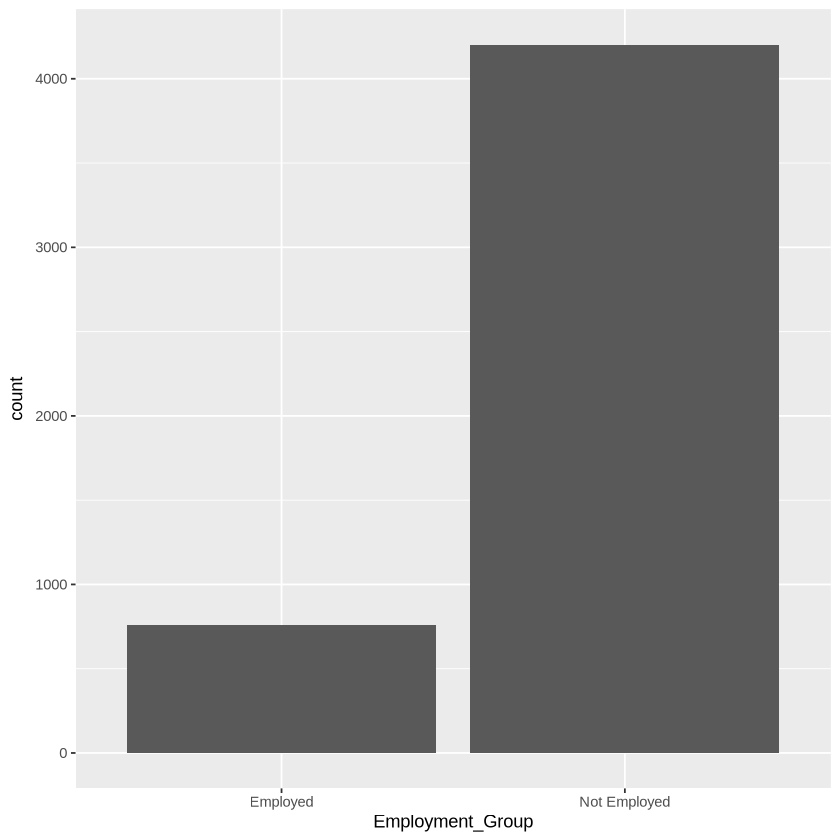

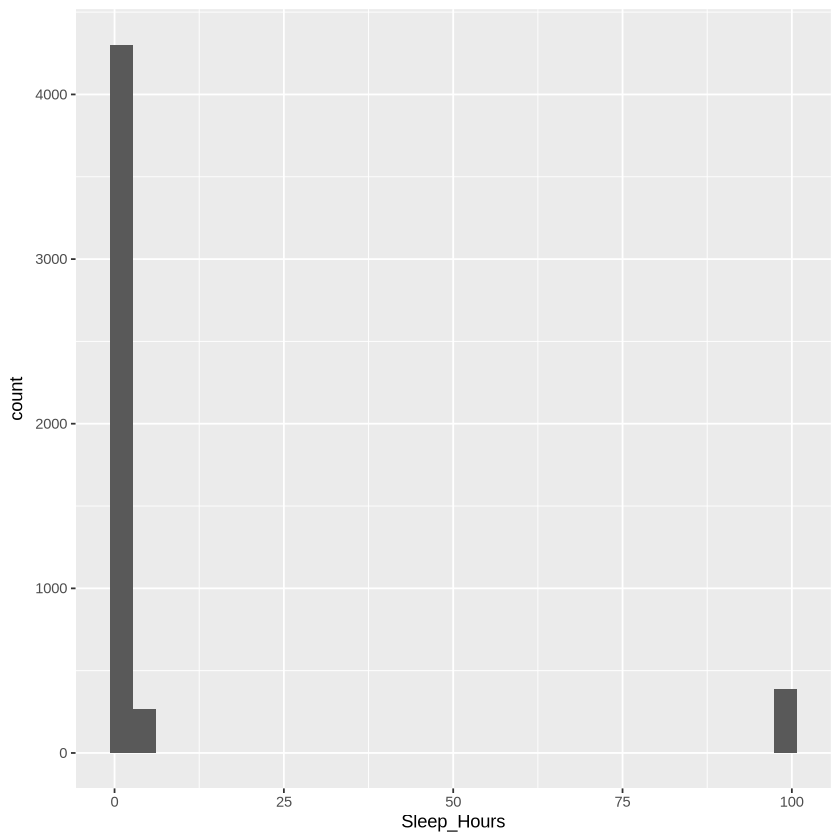

In [36]:
#Strategy 2: Compare Working for Pay vs. Not Working (Excluding Retired/Students)
#Employment_Group数据数量还是有一定差距
MIUDS_2_selected_4 <- MIUDS_2 |>
                      select(M2ID, B1PB1, B1PB20) |>
                      rename(
                          Respondent_ID = M2ID,
                          Work_Status = B1PB1,
                          Sleep_Hours = B1PB20) |>
                            mutate(
    Employment_Group = ifelse(Work_Status %in% c(1, 2, 3, 4, 8), "Employed", "Not Employed")
  )
head(MIUDS_2_selected_4)
tail(MIUDS_2_selected_4)
dim(MIUDS_2_selected_4)

employment_plot <- MIUDS_2_selected_4 |>
                   ggplot() +
                   geom_bar(aes(x = Employment_Group))
employment_plot

sleep_hours_plot <- MIUDS_2_selected_4 |>
                    ggplot() +
                    geom_histogram(aes(x = Sleep_Hours))
sleep_hours_plot

Respondent_ID,Work_Status,Sleep_Hours,Employment_Group
<dbl>,<dbl>,<dbl>,<chr>
10010,5,1,Retired
10014,5,1,Retired
10015,5,1,Retired
10018,5,1,Retired
10047,5,99,Retired
10059,5,2,Retired


Respondent_ID,Work_Status,Sleep_Hours,Employment_Group
<dbl>,<dbl>,<dbl>,<chr>
19175,5,2,Retired
19177,5,2,Retired
19181,5,2,Retired
19182,5,1,Retired
19186,5,2,Retired
19191,5,1,Retired


[1] 1280    4

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


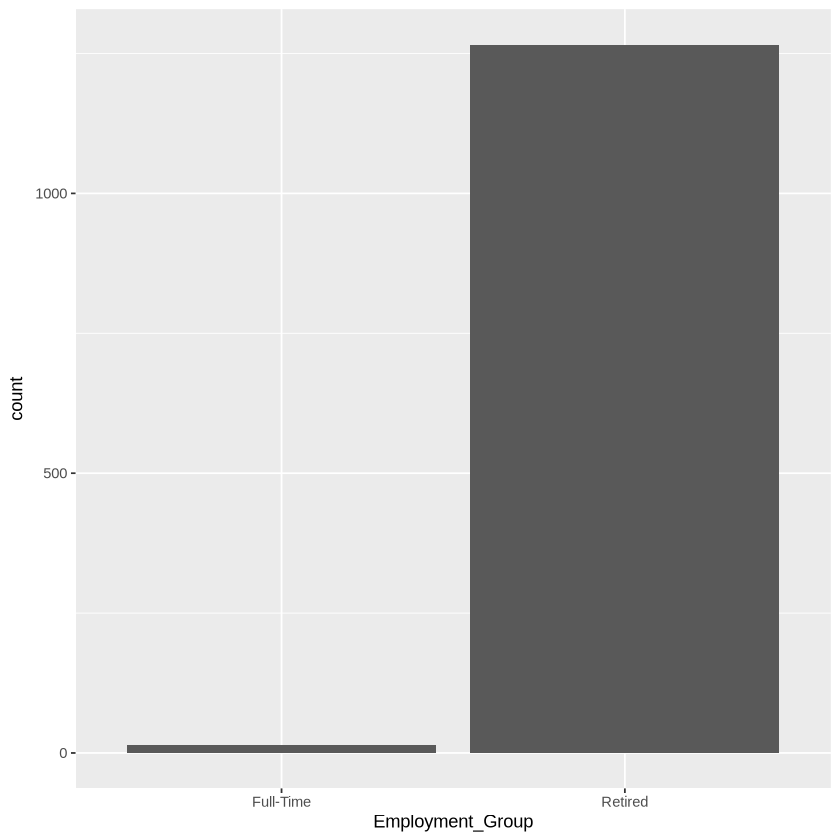

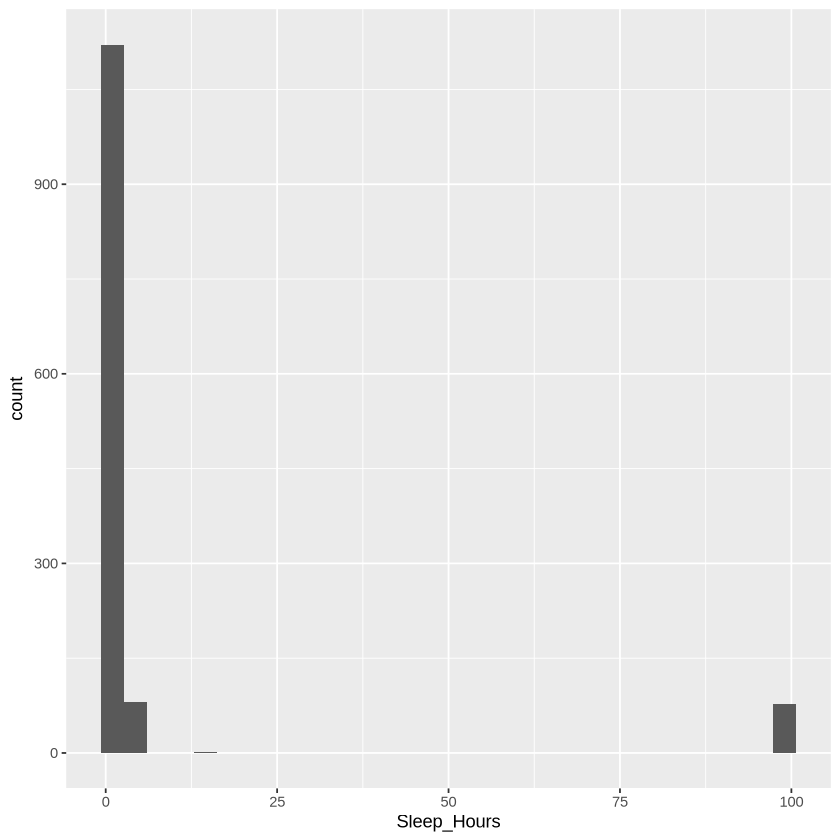

In [37]:
# Strategy 3: Compare Full-Time vs. Retired Only (Most Balanced & Meaningful)
# 这个更极端一些：）
MIUDS_2_selected_4 <- MIUDS_2 |>
                      select(M2ID, B1PB1, B1PB20) |>
                      rename(
                          Respondent_ID = M2ID,
                          Work_Status = B1PB1,
                          Sleep_Hours = B1PB20) |>
                            filter(
    Work_Status %in% c(1, 5), # Keep ONLY Full-Time (1) and Retired (5)
    Sleep_Hours > 0
  ) |>
  mutate(
    Employment_Group = ifelse(Work_Status == 1, "Full-Time", "Retired")
  )
head(MIUDS_2_selected_4)
tail(MIUDS_2_selected_4)
dim(MIUDS_2_selected_4)

employment_plot <- MIUDS_2_selected_4 |>
                   ggplot() +
                   geom_bar(aes(x = Employment_Group))
employment_plot

sleep_hours_plot <- MIUDS_2_selected_4 |>
                    ggplot() +
                    geom_histogram(aes(x = Sleep_Hours))
sleep_hours_plot